# Netflix Movies and TV Shows Analysis

**Course:** Data Analysis Final Project

**Student:** Alva Jönsson

## Project Overview

The purpose of this project is to analyze Netflix's catalog of movies and television shows using data science techniques. The project includes data cleaning, exploratory data analysis (EDA), visualization, regression modeling, and model evaluation.

The primary goal is to identify trends within the Netflix catalog and build machine learning models that predict movie duration based on available features.

# About the Dataset

The dataset used in this project comes from Kaggle and contains information about movies and television shows available on Netflix.

Dataset Link:
https://www.kaggle.com/datasets/shivamb/netflix-shows

The dataset includes descriptive information about each title, including release year, country, rating, genre, cast members, and duration.

This dataset was selected because it provides a variety of categorical and numerical variables that allow for meaningful exploratory data analysis and regression modeling.

# Importing Libraries

Before beginning the analysis, the necessary Python libraries are imported.

These libraries will be used for:

- Loading and manipulating data
- Creating visualizations
- Building regression models
- Evaluating model performance

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Loading the Dataset

The first step is to load the dataset into a pandas DataFrame.

After loading the data, I will display the first few rows to confirm that it has been imported correctly and to gain an initial understanding of its structure.

In [4]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Information
We inspect the dataset using `.info()` and `.describe()`and `df.shape()` to understand:
- Data types
- Missing values
- Statistical summary
- Overall structure

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [7]:
df.shape

(8807, 12)

## Missing Values

The dataset contains missing values in several columns such as director, cast, country, and rating.

To handle this:
- Categorical missing values are replaced with "Unknown"
- Rating missing values are replaced with the most frequent category (mode)

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["date_added"] = df["date_added"].fillna("Unknown")

## Remove Duplicates

We check for duplicate records to ensure data quality. No duplicates are found in this dataset.

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

## Feature Engineering

The `duration` column contains text values such as `"90 min"` for movies and `"2 Seasons"` for TV shows. To use this information in regression models, a new numeric column called `duration_num` is created by extracting the numerical portion of the text.

In [15]:
df["duration_num"] = df["duration"].str.extract(r'(\d+)').astype(float)

df[["duration", "duration_num"]].head()

,duration,duration_num
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0


In [16]:
df["type"] = df["type"].map({
    "Movie":0,
    "TV Show":1
})

In [17]:
df = pd.get_dummies(df, columns=["rating"], drop_first=True)

## Exploratory Data Analysis

### Distribution of Release Year
This visualization shows how Netflix content is distributed over time. It helps us understand the growth of Netflix content over different decades.

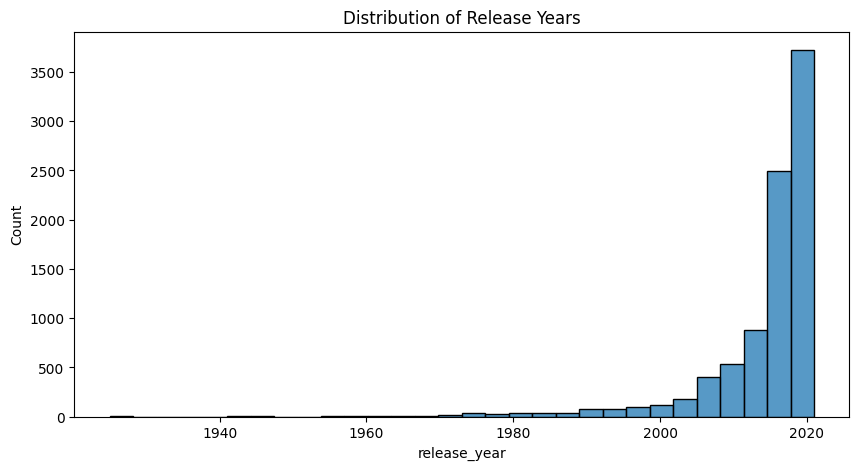

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df["release_year"], bins=30)

plt.title("Distribution of Release Years")
plt.show()

##### Most Netflix content was released after 2000, with a noticeable increase during the 2010s.

### Movies VS TV shows 
This visualization shows how Netflix content is distributed over time. It helps us understand the growth of Netflix content over different decades.


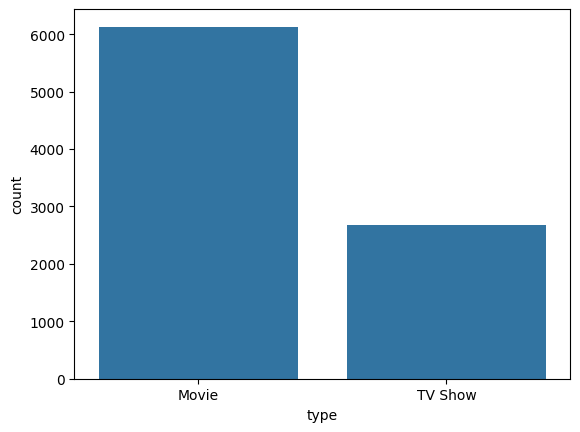

In [19]:
sns.countplot(x=df["type"])
plt.xticks([0,1],["Movie","TV Show"])
plt.show()

##### Movies make up the majority of Netflix's catalog.

## Top Countries

##### This bar chart shows the top 10 countries that produce the most content available on Netflix.

We use the `value_counts()` function on the `country` column to count how many titles come from each country. Then, we select the top 10 most frequent countries and visualize the results using a bar chart.

This helps us understand which countries dominate Netflix’s content library and gives insight into global content distribution trends.

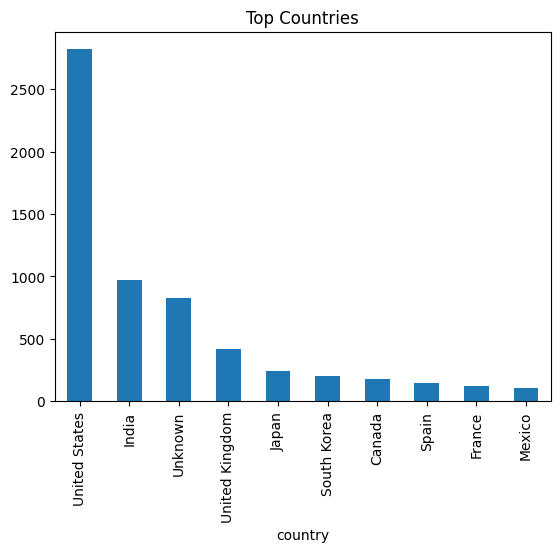

In [20]:
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top Countries")
plt.show()

## Top Ratings

This visualization shows how Netflix content is distributed across different audience ratings such as TV-MA, TV-14, and PG.


In [23]:
df = pd.read_csv("netflix_titles.csv")
df.columns = df.columns.str.strip()

In [24]:
"rating" in df.columns

True

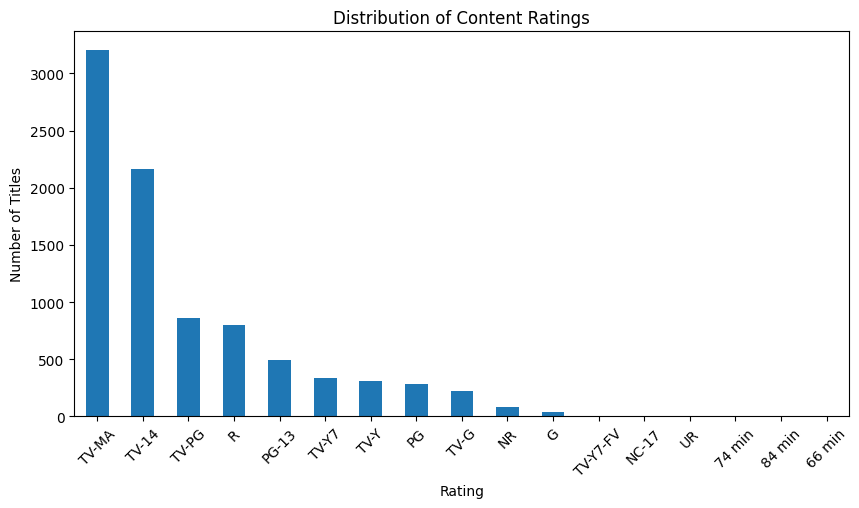

In [25]:
plt.figure(figsize=(10,5))

df["rating"].value_counts().plot(kind="bar")

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

### Duration Distribution

This visualization shows the distribution of movie durations in the dataset.

A histogram is used to understand how movie lengths are spread and to identify common duration ranges.

This helps us understand whether most movies are short, medium, or long in duration.

In [28]:
df["duration"] = df["duration"].astype(str)
df["duration_num"] = df["duration"].str.extract(r'(\d+)').astype(float)

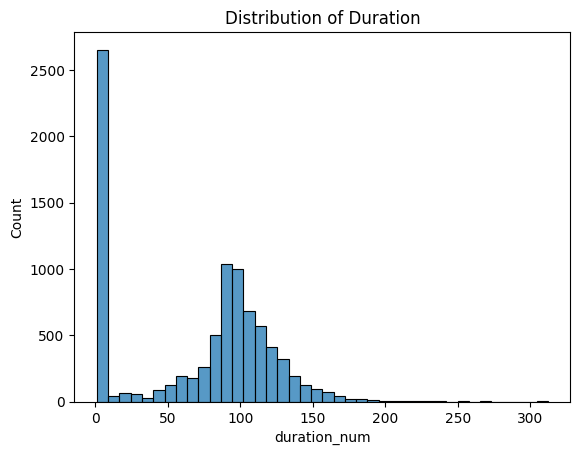

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["duration_num"], bins=40)

plt.title("Distribution of Duration")
plt.show()

### Correlation Heatmap 

This heatmap displays the correlation between all numerical variables in the dataset.

Correlation helps identify relationships between features, such as whether release year or duration has any meaningful relationship with other numeric variables.

The `coolwarm` color map is used to make positive and negative correlations easier to interpret visually.

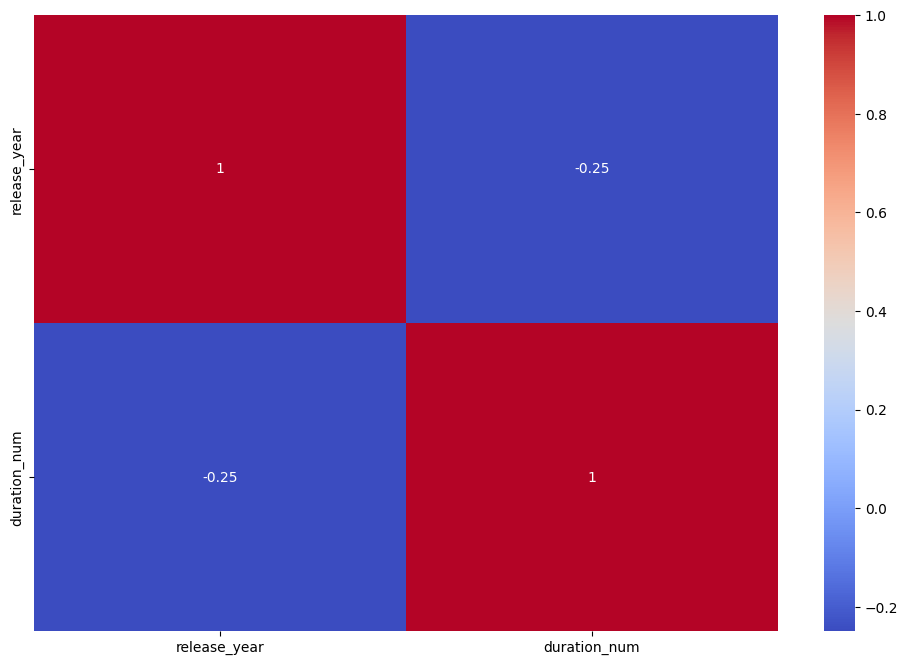

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

### Outlier Analysis

In this section, we use boxplots and the IQR (Interquartile Range) method to detect outliers in the dataset.

Outliers are values that are significantly higher or lower than most of the data points.

We specifically analyze:
- Movie duration (`duration_num`)
- Release year (`release_year`)

<Axes: xlabel='duration_num'>

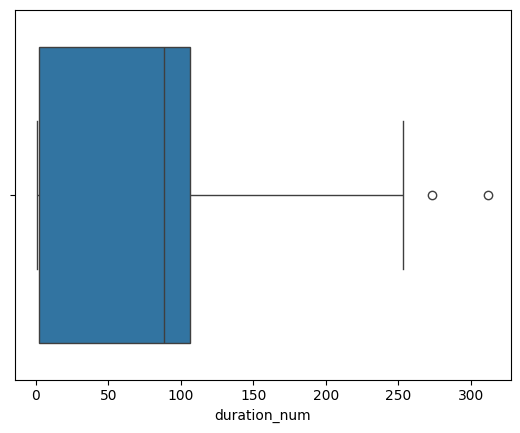

In [31]:
sns.boxplot(x=df["duration_num"])

<Axes: xlabel='release_year'>

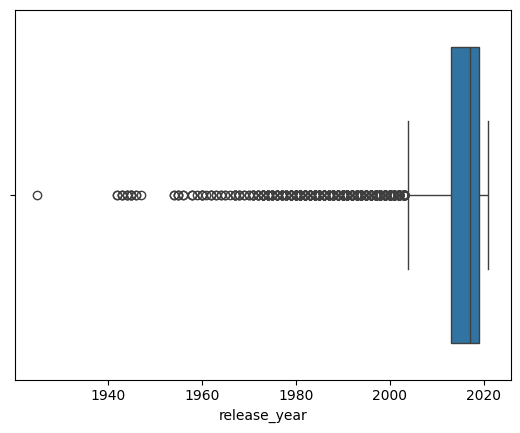

In [32]:
sns.boxplot(x=df["release_year"])

In [33]:
Q1 = df["duration_num"].quantile(.25)
Q3 = df["duration_num"].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[(df["duration_num"]<lower) | (df["duration_num"]>upper)]

outliers

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num
717,s718,Movie,Headspace: Unwind Your Mind,NaN,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",NaN,"June 15, 2021",2021,TV-G,273 min,Documentaries,"Do you want to relax, meditate or sleep deeply...",273.0
4253,s4254,Movie,Black Mirror: Bandersnatch,NaN,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,"December 28, 2018",2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312.0


### Modeling

In this section, we build machine learning models to predict the release year of a movie based on its duration.

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [34]:
X = df[["duration_num"]]

y = df["release_year"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=.2,
    random_state=42
)

#### Linear Regression

A Linear Regression model is used as a baseline model.

It assumes a linear relationship between movie duration and release year.

We evaluate the model using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² score

In [39]:
X_train.isnull().sum()

duration_num    2
dtype: int64

In [40]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           0
listed_in          0
description        0
duration_num       3
dtype: int64

In [41]:
df_model = df[["duration_num", "release_year"]].dropna()

In [42]:
X = df_model[["duration_num"]]
y = df_model["release_year"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

In [42]:
X = df_model[["duration_num"]]
y = df_model["release_year"]

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 5.389959233271981
RMSE: 9.45066466419791
R2: 0.04630359707636378


### Polynomial Regression

Polynomial Regression is used to capture non-linear relationships between variables.

By increasing the degree of the polynomial (degree = 2), the model can fit more complex patterns in the data.

This helps improve performance compared to simple linear regression in some cases.

In [46]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train,y_train)

pred_poly = poly_model.predict(X_test)

In [47]:
print("MAE:",mean_absolute_error(y_test,pred_poly))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_poly)))
print("R2:",r2_score(y_test,pred_poly))

MAE: 5.295897052717159
RMSE: 9.396287071696468
R2: 0.05724685239452676


### Ridge Regression

Ridge Regression is a regularized version of linear regression.

It adds a penalty term (alpha) to reduce overfitting and improve model generalization.

This model is useful when dealing with noisy or highly correlated data.

In [48]:
ridge = Ridge(alpha=1)

ridge.fit(X_train,y_train)

pred_ridge = ridge.predict(X_test)

In [49]:
print("MAE:",mean_absolute_error(y_test,pred_ridge))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_ridge)))
print("R2:",r2_score(y_test,pred_ridge))

MAE: 5.38995922352496
RMSE: 9.450664662448006
R2: 0.04630359742954071


### Multi-variable Regression

In this section, we extend our model to include multiple features instead of using only one predictor.

We create a feature set that includes:
- `duration_num` (movie duration)
- `type` (Movie or TV Show)
- All rating-related dummy variables

This allows the model to learn from more information and potentially improve prediction performance compared to single-variable regression.

In [56]:
features = ["duration_num","type"]

In [57]:
rating_cols = [c for c in df.columns if c.startswith("rating_")]

features += rating_cols

### Hyperparameter Tuning

To improve the Ridge Regression model, we use GridSearchCV to find the best value of the hyperparameter `alpha`.

We test multiple values:
- 0.01
- 0.1
- 1
- 10
- 50
- 100

Cross-validation (cv=5) is used to ensure the model generalizes well across different data splits.

The best parameter is selected based on the highest R² score.

In [52]:
param_grid = {
    "alpha":[0.01,0.1,1,10,50,100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [53]:
print(grid.best_params_)
print(grid.best_score_)

{'alpha': 100}
0.06661146714283721


In [54]:
best = grid.best_estimator_

pred = best.predict(X_test)

In [55]:
print(mean_absolute_error(y_test,pred))
print(np.sqrt(mean_squared_error(y_test,pred)))
print(r2_score(y_test,pred))

5.389958258575535
9.450664489216054
0.046303632392306504


## Model Evaluation

We evaluate the final model using three standard regression metrics:

- MAE (Mean Absolute Error): average prediction error
- RMSE (Root Mean Squared Error): penalizes large errors more heavily
- R² Score: measures how well the model explains the variance in the data

These metrics help us understand the overall performance of the tuned model.

All models have low R² scores. This shows that the features do not have a strong linear relationship with the target variable. It also shows that improving the features is more important than using more complex models

## Results

The model performance after hyperparameter tuning shows:

- Best alpha value found: 100
- R² score remains relatively low (~0.04–0.06)

This suggests that the current features do not strongly explain the variation in the target variable (release year), and further feature engineering may be needed to improve performance.

## Conclusion 

In this project, we compared Linear, Polynomial, and Ridge Regression models using the Netflix dataset. All models showed similar and low performance, which means the data does not have strong linear relationships. Ridge Regression performed slightly better, but overall results suggest that better feature engineering is needed

## References

- Shivam Bansal (Kaggle Dataset): Netflix Movies and TV Shows  
  https://www.kaggle.com/datasets/shivamb/netflix-shows

- Python Software Foundation: Python Programming Language  
  https://www.python.org/

- Pandas Documentation  
  https://pandas.pydata.org/docs/

- NumPy Documentation  
  https://numpy.org/doc/

- Matplotlib Documentation  
  https://matplotlib.org/stable/contents.html

- Seaborn Documentation  
  https://seaborn.pydata.org/

- Scikit-learn Documentation  
  https://scikit-learn.org/stable/

This project uses open-source Python libraries for data analysis, visualization, and machine learning.